# Notebook 04 — EDA Estadístico y Feature Engineering

**Proyecto Fin de Máster — MUCSI, Universidad de Deusto**  
**Dataset:** REFIT Electrical Load Measurements (Zenodo doi:10.5281/zenodo.5063428)  
**Datos de entrada:** `datos/processed/house{1,2,3}_1min_limpio.csv`  
**Objetivo:** Análisis estadístico profundo de los datos limpios + construcción de features
para el posterior modelado predictivo.

---

## Índice
1. [Configuración e importaciones](#1)
2. [Carga de datos procesados](#2)
3. [Análisis de valores ausentes (NaN)](#3)
4. [Tests de estacionariedad — ADF y KPSS](#4)
5. [Descomposición estacional](#5)
6. [Autocorrelación — ACF y PACF](#6)
7. [Correlaciones entre electrodomésticos](#7)
8. [Distribuciones estadísticas](#8)
9. [Feature Engineering](#9)
10. [Correlación de features con el target](#10)
11. [Guardado y verificación final](#11)

## 1. Configuración e importaciones <a id='1'></a>

In [1]:
# ============================================================
# Importaciones y configuración global
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy
import statsmodels
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Semilla global de reproducibilidad
SEMILLA = 42
np.random.seed(SEMILLA)
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# Festivos bancarios England & Wales cubiertos por el dataset
# Fuente: https://www.gov.uk/bank-holidays
# Se usa lista manual para evitar dependencia extra; si la
# librería 'holidays' está instalada, se sobrescribe automáticamente.
# -------------------------------------------------------
FESTIVOS_UK = {
    pd.Timestamp('2013-08-26'), pd.Timestamp('2013-12-25'), pd.Timestamp('2013-12-26'),
    pd.Timestamp('2014-01-01'), pd.Timestamp('2014-04-18'), pd.Timestamp('2014-04-21'),
    pd.Timestamp('2014-05-05'), pd.Timestamp('2014-05-26'), pd.Timestamp('2014-08-25'),
    pd.Timestamp('2014-12-25'), pd.Timestamp('2014-12-26'),
    pd.Timestamp('2015-01-01'), pd.Timestamp('2015-04-03'), pd.Timestamp('2015-04-06'),
    pd.Timestamp('2015-05-04'), pd.Timestamp('2015-05-25'),
}

try:
    import holidays as hol_lib
    _festivos_dict = {}
    for _anyo in [2013, 2014, 2015]:
        _festivos_dict.update(hol_lib.country_holidays('GB', subdiv='ENG', years=_anyo))
    FESTIVOS_UK = {pd.Timestamp(d) for d in _festivos_dict.keys()}
    print(f"Librería 'holidays' disponible: {len(FESTIVOS_UK)} festivos cargados (2013-2015)")
except ImportError:
    print(f"Usando lista manual de festivos UK: {len(FESTIVOS_UK)} días.")
    print("  Para usar librería oficial: pip install holidays")

# Estilo de gráficos unificado
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
plt.rcParams.update({
    'figure.dpi'    : 120,
    'figure.figsize': (14, 5),
    'font.size'     : 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Rutas del proyecto
RUTA_PROCESSED = '../datos/processed/'
RUTA_FIGS      = '../resultados/figuras/'
RUTA_MET       = '../resultados/metricas/'

os.makedirs(RUTA_FIGS, exist_ok=True)
os.makedirs(RUTA_MET,  exist_ok=True)

HOGARES      = ['House1', 'House2', 'House3']
COLS_CONSUMO = ['Aggregate'] + [f'Appliance{i}' for i in range(1, 10)]

# Lookup vectorizable mes → estación (evita apply row-by-row en 900K filas)
_ESTACION_MAP = {
    1: 'Invierno', 2: 'Invierno', 12: 'Invierno',
    3: 'Primavera', 4: 'Primavera', 5: 'Primavera',
    6: 'Verano', 7: 'Verano', 8: 'Verano',
    9: 'Otono', 10: 'Otono', 11: 'Otono',
}

print('\n=== Versiones de librerías ===')
print(f'  pandas      : {pd.__version__}')
print(f'  numpy       : {np.__version__}')
print(f'  statsmodels : {statsmodels.__version__}')
print(f'  scipy       : {scipy.__version__}')
print(f'  SEMILLA     : {SEMILLA}')
print('==============================')

Usando lista manual de festivos UK: 16 días.
  Para usar librería oficial: pip install holidays

=== Versiones de librerías ===
  pandas      : 2.2.3
  numpy       : 2.0.2
  statsmodels : 0.14.6
  scipy       : 1.14.1
  SEMILLA     : 42


## 2. Carga de datos procesados <a id='2'></a>

In [2]:
# ============================================================
# Carga de los tres datasets limpios desde datos/processed/
# Estos DataFrames ya tienen índice temporal y granularidad 1 min.
# ============================================================

datos = {}
for hogar in HOGARES:
    ruta = os.path.join(RUTA_PROCESSED, f'{hogar.lower()}_1min_limpio.csv')
    df   = pd.read_csv(ruta, index_col='timestamp', parse_dates=True)
    datos[hogar] = df
    pct_nan = df['Aggregate'].isna().mean() * 100
    print(f'{hogar}: {len(df):,} filas | Aggregate NaN: {pct_nan:.2f}% | '
          f'{df.index.min().date()} → {df.index.max().date()}')

print('\nCarga completada.')

House1: 920,091 filas | Aggregate NaN: 12.03% | 2013-10-09 → 2015-07-10


House2: 889,078 filas | Aggregate NaN: 23.69% | 2013-09-17 → 2015-05-28


House3: 885,095 filas | Aggregate NaN: 12.43% | 2013-09-25 → 2015-06-02

Carga completada.


## 3. Análisis de valores ausentes (NaN) <a id='3'></a>

Los NaN en los datos procesados proceden de dos fuentes:
1. **Huecos largos (> 30 min)** en la serie original — no se interpolaron para no fabricar datos.
2. **Outliers (Aggregate > 15.000 W)** reemplazados por NaN en el Notebook 03.

Se analiza aquí la distribución temporal para identificar si los huecos se concentran
en períodos concretos, lo que afectaría a la estrategia de modelado (split temporal).

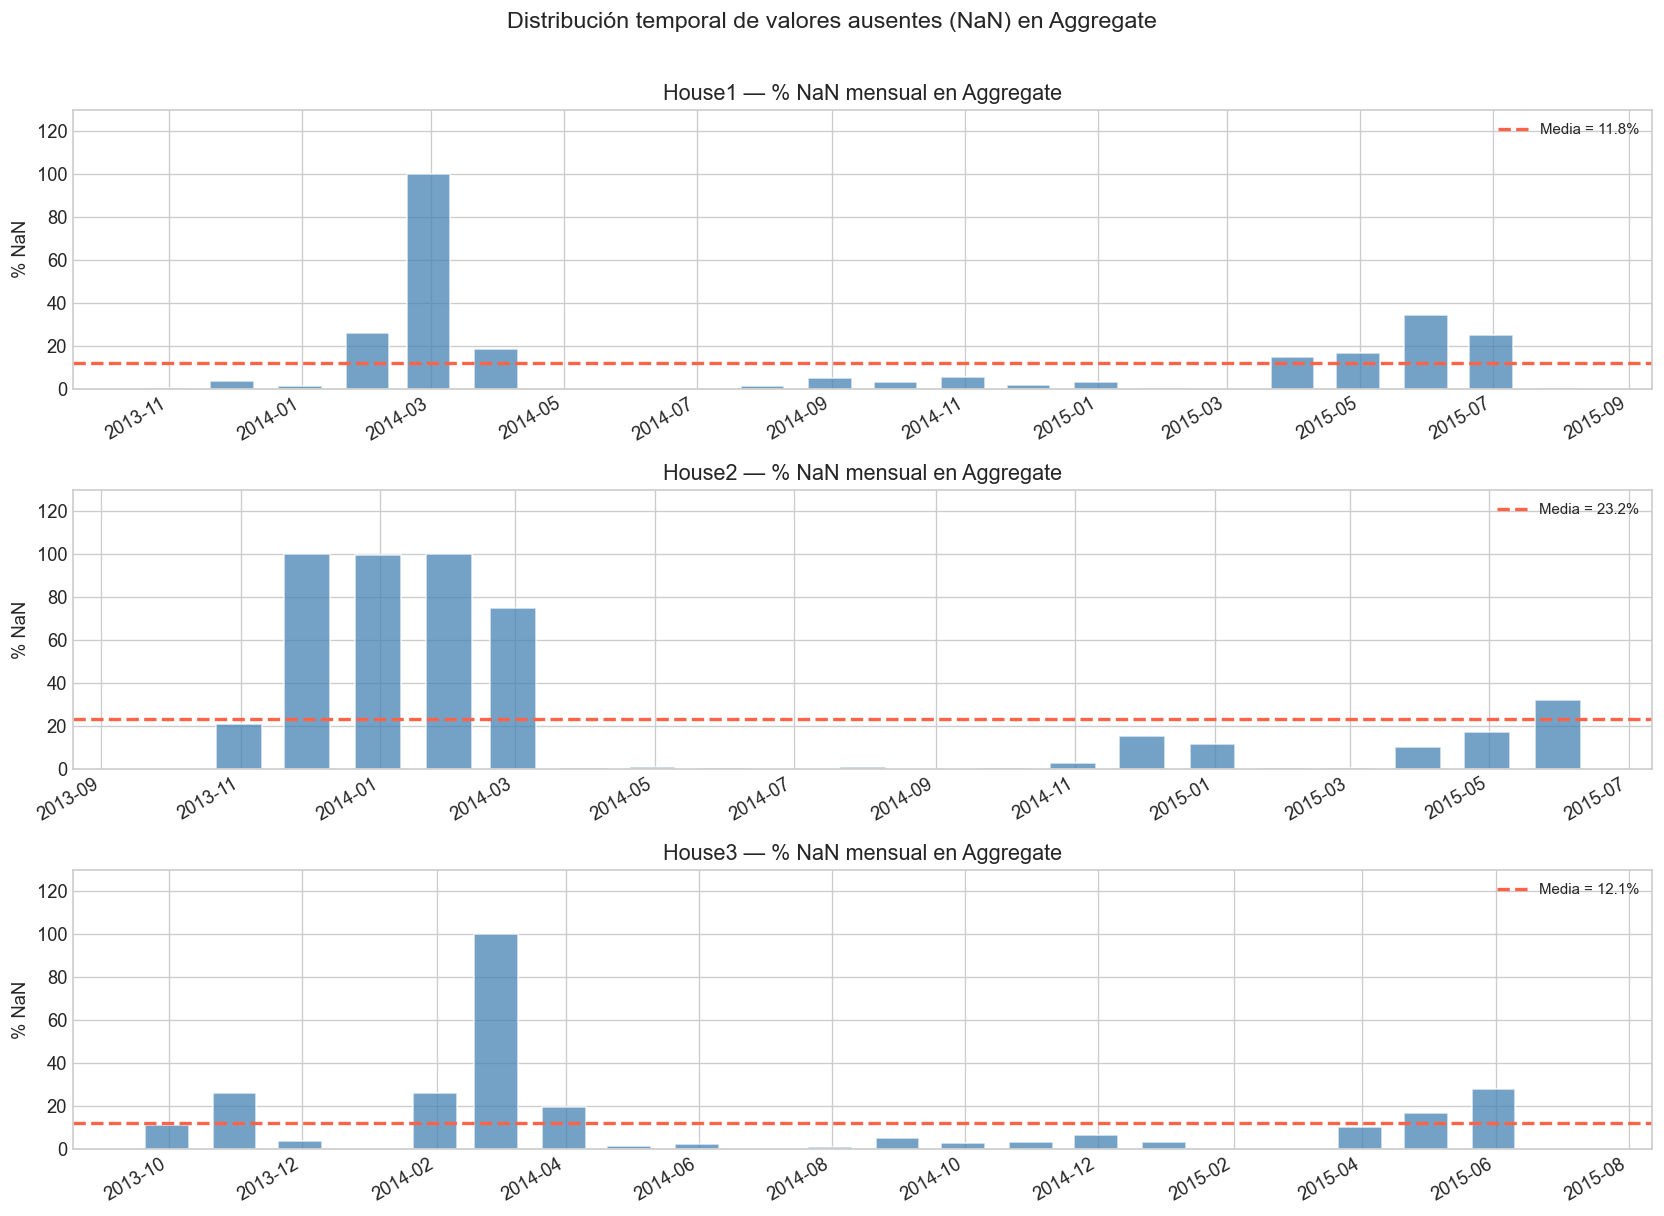

=== Resumen de valores ausentes ===


,Total NaN,% NaN global,Num. gaps,Gap med. (min),Gap max. (min),Mes más afectado,% NaN ese mes
Hogar,,,,,,,
House1,"110,680",12.03%,54,44,59876,2014-02,100.0%
House2,"210,644",23.69%,109,107,89284,2013-11,100.0%
House3,"110,006",12.43%,238,33,59876,2014-02,100.0%


In [3]:
# ============================================================
# Porcentaje mensual de NaN en Aggregate — los 3 hogares
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

resumen_nan = []
for ax, hogar in zip(axes, HOGARES):
    serie       = datos[hogar]['Aggregate']
    mascara_nan = serie.isna()                             # cachear: se reutiliza 4 veces
    pct_mensual = mascara_nan.resample('ME').mean() * 100

    ax.bar(pct_mensual.index, pct_mensual.values,
           width=20, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axhline(pct_mensual.mean(), color='tomato', lw=2, linestyle='--',
               label=f'Media = {pct_mensual.mean():.1f}%')
    ax.set_title(f'{hogar} — % NaN mensual en Aggregate')
    ax.set_ylabel('% NaN')
    ax.set_ylim(0, max(pct_mensual.max() * 1.3, 5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)

    # Calcular longitud de gaps usando la máscara ya computada
    grupos = (mascara_nan != mascara_nan.shift()).cumsum()
    gaps   = mascara_nan.groupby(grupos).sum()
    gaps   = gaps[gaps > 0]

    resumen_nan.append({
        'Hogar'           : hogar,
        'Total NaN'       : f"{mascara_nan.sum():,}",
        '% NaN global'    : f"{mascara_nan.mean()*100:.2f}%",
        'Num. gaps'       : len(gaps),
        'Gap med. (min)'  : f"{gaps.median():.0f}",
        'Gap max. (min)'  : f"{gaps.max():.0f}",
        'Mes más afectado': pct_mensual.idxmax().strftime('%Y-%m'),
        '% NaN ese mes'   : f"{pct_mensual.max():.1f}%",
    })

plt.suptitle('Distribución temporal de valores ausentes (NaN) en Aggregate', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '04_nan_patrones.png'), bbox_inches='tight')
plt.show()

df_resumen_nan = pd.DataFrame(resumen_nan).set_index('Hogar')
print('=== Resumen de valores ausentes ===')
display(df_resumen_nan)

## 4. Tests de estacionariedad — ADF y KPSS <a id='4'></a>

La estacionariedad es una propiedad fundamental para los modelos de series temporales:
- **ADF (Augmented Dickey-Fuller):** H₀ = raíz unitaria (no estacionario). Se rechaza si p < 0,05.
- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):** H₀ = serie estacionaria. Se rechaza si p < 0,05.

Usar ambos tests de forma complementaria da mayor robustez: si ADF rechaza H₀ y KPSS
no rechaza H₀, se puede concluir que la serie es estacionaria con alta confianza.

> **Nota:** Los tests se aplican sobre la serie con NaN eliminados (no imputados).
> Para acelerar el cómputo se usa una muestra de 30 días por hogar, suficiente para
> capturar la estructura estocástica de la serie.

In [4]:
# ============================================================
# Tests ADF y KPSS sobre muestra de 30 días sin NaN
# ============================================================

DIAS_MUESTRA_TEST = 30  # días para los tests de estacionariedad

resultados_est = []

for hogar in HOGARES:
    serie = datos[hogar]['Aggregate']

    # index[0] es O(1) en un índice ya ordenado; index.min() sería O(n)
    inicio    = serie.index[0]
    fin_muest = inicio + pd.Timedelta(days=DIAS_MUESTRA_TEST)
    muestra   = serie.loc[inicio:fin_muest].dropna()

    # --- Test ADF ---
    adf_stat, adf_p, adf_lags, _, adf_cv, _ = adfuller(muestra, autolag='AIC')
    adf_estacionaria = adf_p < 0.05

    # --- Test KPSS ---
    kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(muestra, regression='c', nlags='auto')
    kpss_estacionaria = kpss_p >= 0.05

    # Conclusión conjunta derivada de los booleanos (evita comparar strings)
    if adf_estacionaria and kpss_estacionaria:
        conclusion_final = 'ESTACIONARIA (ambos tests)'
    elif not adf_estacionaria and not kpss_estacionaria:
        conclusion_final = 'NO ESTACIONARIA (ambos tests)'
    elif adf_estacionaria:
        conclusion_final = 'POSIBLEMENTE estacionaria (diferencia ADF/KPSS)'
    else:
        conclusion_final = 'DIFERENCIA entre tests — revisar'

    adf_txt  = 'ESTACIONARIA' if adf_estacionaria else 'NO ESTACIONARIA'
    kpss_txt = 'ESTACIONARIA' if kpss_estacionaria else 'NO ESTACIONARIA'

    print(f'\n=== {hogar} (muestra: {len(muestra):,} puntos) ===')
    print(f'  ADF  → estadístico: {adf_stat:.4f} | p-valor: {adf_p:.6f} | '
          f'lags AIC: {adf_lags} | Conclusión: {adf_txt}')
    print(f'       CV 1%: {adf_cv["1%"]:.4f} | CV 5%: {adf_cv["5%"]:.4f} | CV 10%: {adf_cv["10%"]:.4f}')
    print(f'  KPSS → estadístico: {kpss_stat:.4f} | p-valor: {kpss_p:.6f} | '
          f'lags: {kpss_lags} | Conclusión: {kpss_txt}')
    print(f'  ▶ Conclusión final: {conclusion_final}')

    resultados_est.append({
        'Hogar'           : hogar,
        'Muestra (puntos)': len(muestra),
        'ADF estadístico' : round(adf_stat, 4),
        'ADF p-valor'     : round(adf_p, 6),
        'ADF conclusión'  : adf_txt,
        'KPSS estadístico': round(kpss_stat, 4),
        'KPSS p-valor'    : round(kpss_p, 6),
        'KPSS conclusión' : kpss_txt,
        'Conclusión final': conclusion_final,
    })

df_estacionariedad = pd.DataFrame(resultados_est).set_index('Hogar')
df_estacionariedad.to_csv(os.path.join(RUTA_MET, '04_resumen_estacionariedad.csv'))
print('\nCSV guardado: resultados/metricas/04_resumen_estacionariedad.csv')


=== House1 (muestra: 41,622 puntos) ===
  ADF  → estadístico: -13.8290 | p-valor: 0.000000 | lags AIC: 55 | Conclusión: ESTACIONARIA
       CV 1%: -3.4305 | CV 5%: -2.8616 | CV 10%: -2.5668
  KPSS → estadístico: 4.3054 | p-valor: 0.010000 | lags: 103 | Conclusión: NO ESTACIONARIA
  ▶ Conclusión final: POSIBLEMENTE estacionaria (diferencia ADF/KPSS)



=== House2 (muestra: 43,201 puntos) ===
  ADF  → estadístico: -20.6721 | p-valor: 0.000000 | lags AIC: 55 | Conclusión: ESTACIONARIA
       CV 1%: -3.4305 | CV 5%: -2.8616 | CV 10%: -2.5668
  KPSS → estadístico: 0.0872 | p-valor: 0.100000 | lags: 97 | Conclusión: ESTACIONARIA
  ▶ Conclusión final: ESTACIONARIA (ambos tests)



=== House3 (muestra: 30,721 puntos) ===
  ADF  → estadístico: -12.9043 | p-valor: 0.000000 | lags AIC: 50 | Conclusión: ESTACIONARIA
       CV 1%: -3.4306 | CV 5%: -2.8616 | CV 10%: -2.5668
  KPSS → estadístico: 0.6847 | p-valor: 0.014935 | lags: 96 | Conclusión: NO ESTACIONARIA
  ▶ Conclusión final: POSIBLEMENTE estacionaria (diferencia ADF/KPSS)

CSV guardado: resultados/metricas/04_resumen_estacionariedad.csv


## 5. Descomposición estacional <a id='5'></a>

La descomposición clásica separa la serie en:
- **Tendencia (trend):** cambio de nivel a largo plazo.
- **Componente estacional:** patrón que se repite con periodicidad fija (aquí 1 día = 1440 minutos).
- **Residuo:** variación no explicada por tendencia ni estacionalidad.

Se usa el modelo **aditivo** (`Yt = Tt + St + Rt`) ya que el rango del consumo no varía
proporcionalmente con el nivel — las oscilaciones diarias tienen amplitud similar
independientemente del consumo medio de ese período.

Por limitaciones de cómputo y de la función `seasonal_decompose`, se usa una muestra
de **14 días consecutivos** de House1 sin NaN.

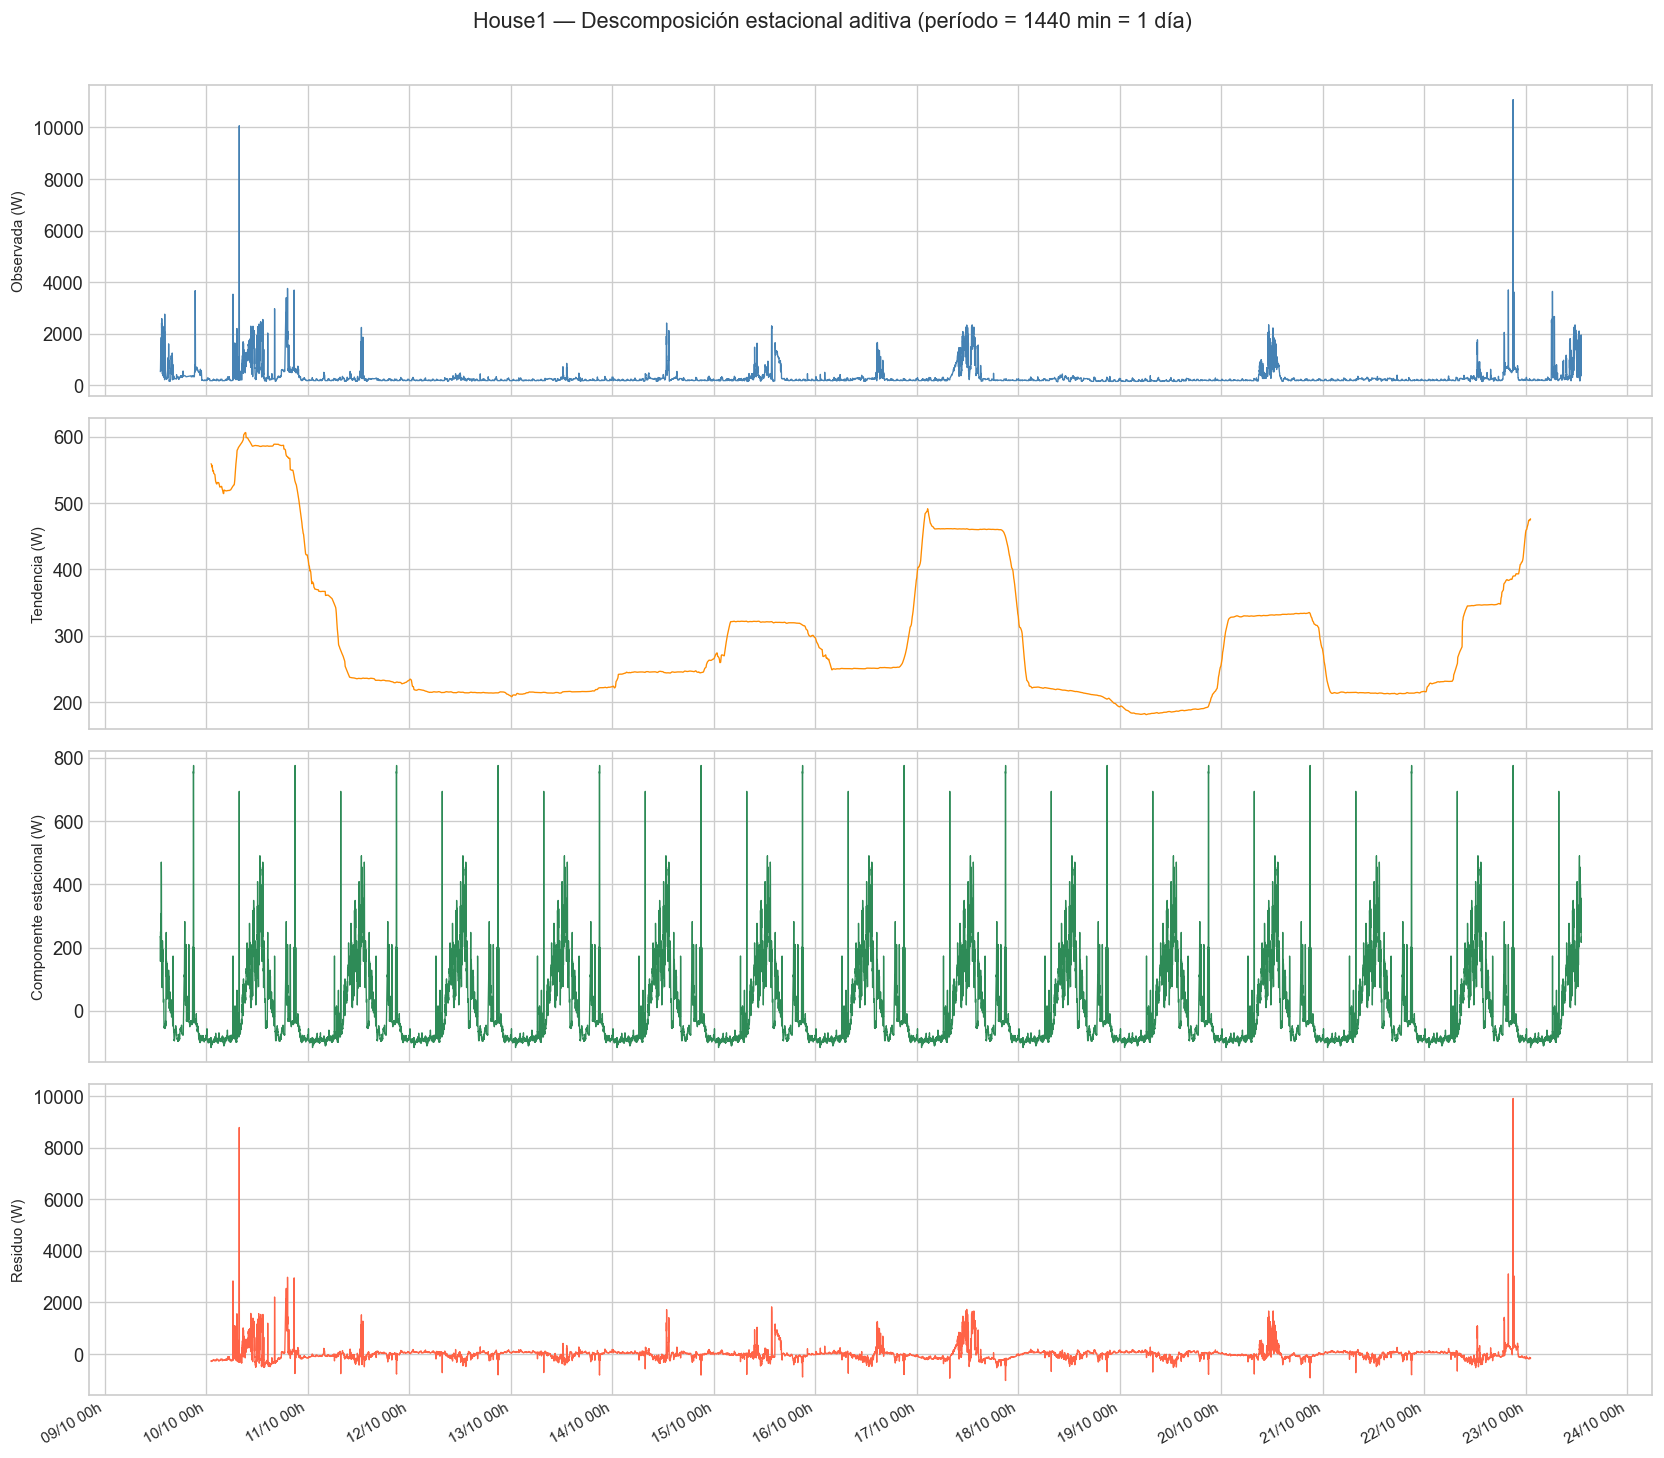

Fuerza del componente estacional diario: 0.1475
  (0 = sin estacionalidad, 1 = estacionalidad perfecta)
  Interpretación: BAJA


In [5]:
# ============================================================
# Descomposición estacional — House1, 14 días continuos
# Período = 1440 min (1 día en datos de 1 minuto)
# ============================================================

PERIODO_DESCOMP = 1440  # minutos en un día
DIAS_DESCOMP    = 14

serie_h1 = datos['House1']['Aggregate']
inicio   = serie_h1.index[0]   # O(1) en índice ordenado
fin_seg  = inicio + pd.Timedelta(days=DIAS_DESCOMP)
segmento = serie_h1.loc[inicio:fin_seg]

# Rellenar NaN con interpolación lineal para que seasonal_decompose funcione
segmento_completo = segmento.interpolate(method='linear').ffill().bfill()

descomp = seasonal_decompose(segmento_completo, model='additive', period=PERIODO_DESCOMP)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

componentes = [
    (segmento_completo,     'Observada (W)',              'steelblue'),
    (descomp.trend,         'Tendencia (W)',              'darkorange'),
    (descomp.seasonal,      'Componente estacional (W)',  'seagreen'),
    (descomp.resid,         'Residuo (W)',                'tomato'),
]

for ax, (serie, titulo, color) in zip(axes, componentes):
    ax.plot(serie.index, serie.values, color=color, lw=0.8)
    ax.set_ylabel(titulo, fontsize=9)
    ax.tick_params(axis='x', labelsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle(
    f'House1 — Descomposición estacional aditiva (período = {PERIODO_DESCOMP} min = 1 día)',
    y=1.01, fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '04_descomposicion_estacional.png'), bbox_inches='tight')
plt.show()

var_estacional    = descomp.seasonal.dropna().var()
var_residuo       = descomp.resid.dropna().var()
fuerza_estacional = var_estacional / (var_estacional + var_residuo)
print(f'Fuerza del componente estacional diario: {fuerza_estacional:.4f}')
print(f'  (0 = sin estacionalidad, 1 = estacionalidad perfecta)')
print(f'  Interpretación: {"ALTA" if fuerza_estacional > 0.64 else "MODERADA" if fuerza_estacional > 0.3 else "BAJA"}')

## 6. Autocorrelación — ACF y PACF <a id='6'></a>

La función de autocorrelación (ACF) y la autocorrelación parcial (PACF) revelan:
- **ACF:** correlación de la serie consigo misma desplazada `k` pasos (incluye efectos indirectos).
- **PACF:** correlación directa con el lag `k`, eliminando el efecto de lags intermedios.

Estos análisis son esenciales para:
1. Justificar la selección de lags en los modelos predictivos.
2. Determinar el orden (p, d, q) de modelos ARIMA/SARIMA.
3. Confirmar la periodicidad diaria (lag 1440) y semanal (lag 10080).

> **Nota técnica:** se usa una muestra de 7 días de datos limpios (sin NaN) de House1
> con `nlags=2160` (36 horas). Los resultados son representativos de la estructura
> de correlación de toda la serie.

Muestra ACF/PACF: 10,040 puntos | 2160 lags (36.0 horas)


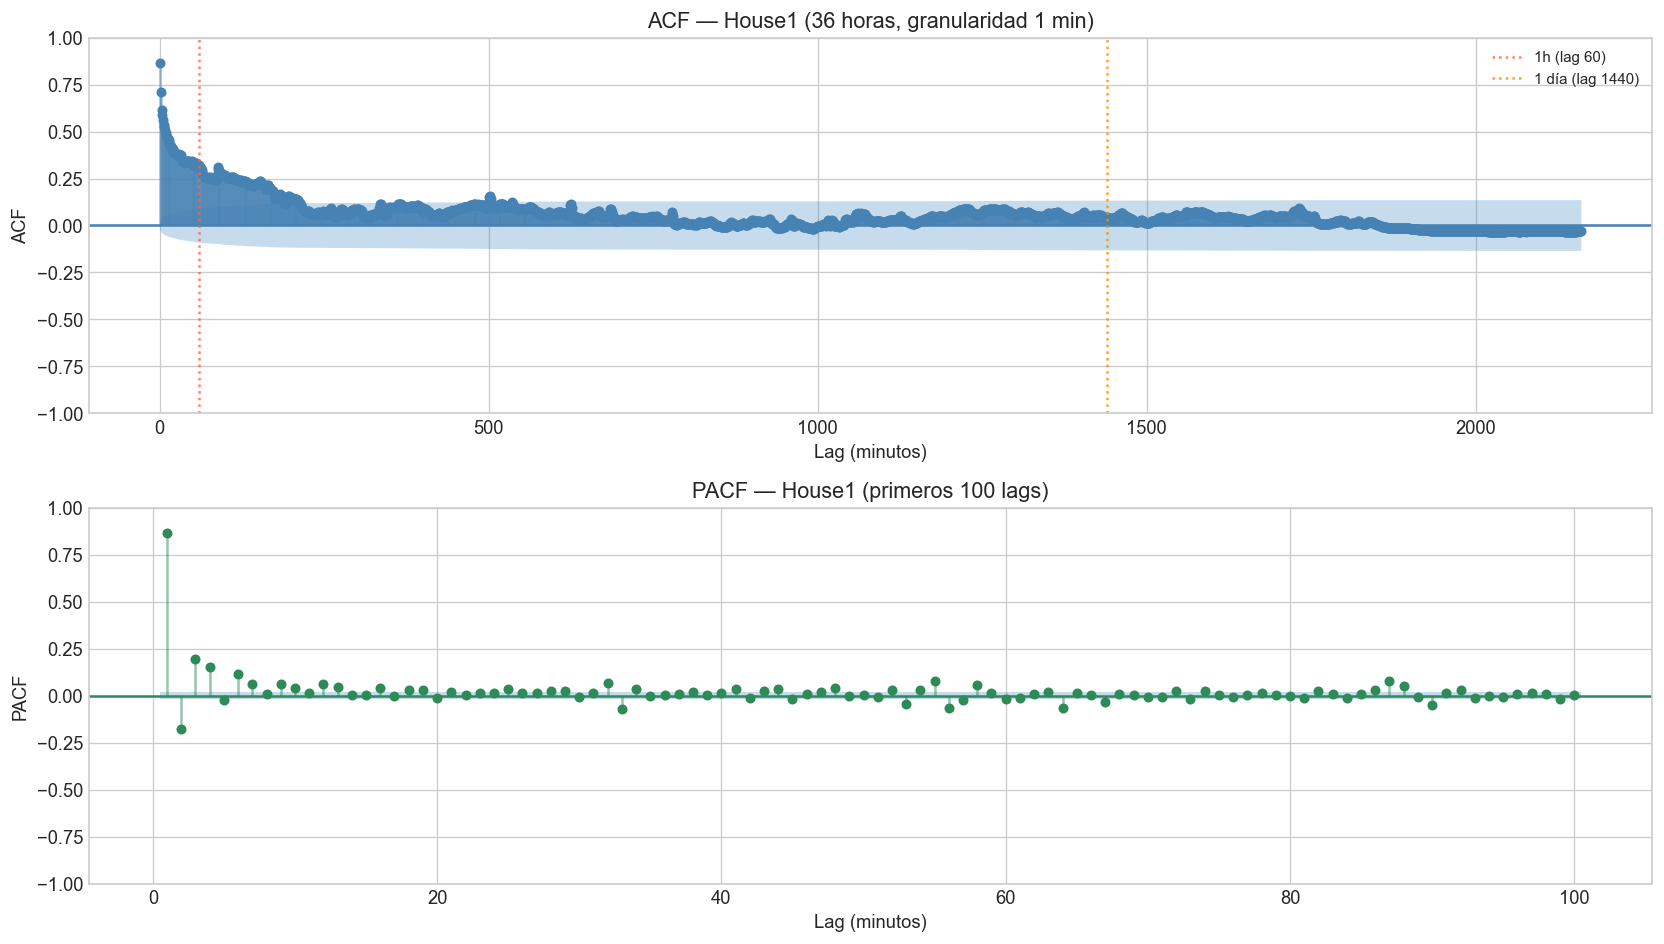

In [6]:
# ============================================================
# ACF y PACF — House1, muestra 7 días sin NaN
# ============================================================

DIAS_ACF  = 7
NLAGS_ACF = 2160  # 36 horas en datos de 1 minuto

serie_acf   = datos['House1']['Aggregate']
inicio_acf  = serie_acf.index[0]   # O(1) en índice ordenado
fin_acf     = inicio_acf + pd.Timedelta(days=DIAS_ACF)
muestra_acf = serie_acf.loc[inicio_acf:fin_acf].dropna()

print(f'Muestra ACF/PACF: {len(muestra_acf):,} puntos | {NLAGS_ACF} lags ({NLAGS_ACF/60:.1f} horas)')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(
    muestra_acf,
    lags=NLAGS_ACF,
    ax=axes[0],
    alpha=0.05,
    zero=False,
    title='ACF — House1 (36 horas, granularidad 1 min)',
    color='steelblue',
    vlines_kwargs={'colors': 'steelblue', 'alpha': 0.5},
)
axes[0].axvline(x=60,   color='tomato',    lw=1.5, linestyle=':', alpha=0.8, label='1h (lag 60)')
axes[0].axvline(x=1440, color='darkorange', lw=1.5, linestyle=':', alpha=0.8, label='1 día (lag 1440)')
axes[0].set_xlabel('Lag (minutos)')
axes[0].set_ylabel('ACF')
axes[0].legend(fontsize=9, loc='upper right')

plot_pacf(
    muestra_acf,
    lags=min(100, len(muestra_acf) // 2 - 1),
    ax=axes[1],
    alpha=0.05,
    zero=False,
    method='ywm',
    title='PACF — House1 (primeros 100 lags)',
    color='seagreen',
    vlines_kwargs={'colors': 'seagreen', 'alpha': 0.5},
)
axes[1].set_xlabel('Lag (minutos)')
axes[1].set_ylabel('PACF')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '04_acf_pacf.png'), bbox_inches='tight')
plt.show()

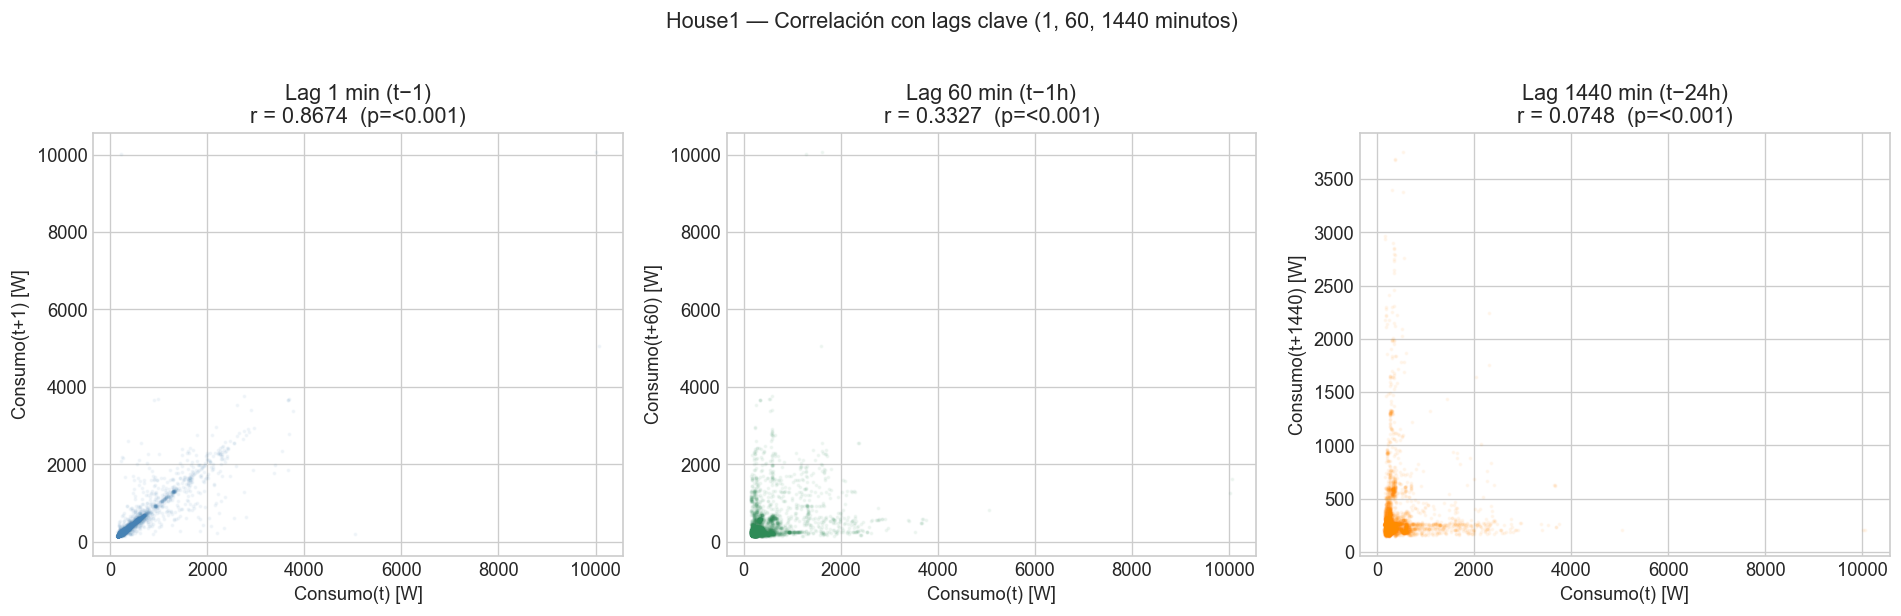

In [7]:
# ============================================================
# Visualización del patrón diario mediante scatter lag-1440
# Un lag-1440 con correlación alta confirma el ciclo de 24h
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lags_visualizar = [1, 60, 1440]
etiquetas       = ['Lag 1 min (t−1)', 'Lag 60 min (t−1h)', 'Lag 1440 min (t−24h)']
colores         = ['steelblue', 'seagreen', 'darkorange']

# Usar House1 sin NaN, muestra de 7 días para el scatter
df_scatter = datos['House1'][['Aggregate']].copy()
df_scatter = df_scatter.dropna()
df_scatter = df_scatter.iloc[:10080]  # 7 días de datos limpios

for ax, lag, etiqueta, color in zip(axes, lags_visualizar, etiquetas, colores):
    x = df_scatter['Aggregate'].values[:-lag]
    y = df_scatter['Aggregate'].values[lag:]
    r, p = stats.pearsonr(x, y)
    p_str = '<0.001' if p < 0.001 else f'{p:.4f}'

    ax.scatter(x, y, alpha=0.05, s=2, color=color)
    ax.set_xlabel('Consumo(t) [W]')
    ax.set_ylabel(f'Consumo(t+{lag}) [W]')
    ax.set_title(f'{etiqueta}\nr = {r:.4f}  (p={p_str})')

plt.suptitle('House1 — Correlación con lags clave (1, 60, 1440 minutos)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '04_scatter_lags.png'), bbox_inches='tight')
plt.show()

## 7. Correlaciones entre electrodomésticos <a id='7'></a>

La matriz de correlación de Pearson entre el consumo agregado y cada electrodoméstico
permite identificar:
- Qué electrodomésticos explican mayor fracción del consumo total.
- Si hay correlaciones cruzadas entre electrodomésticos (uso simultáneo).
- Qué variables auxiliares (electrodomésticos individuales) pueden ser útiles como features.

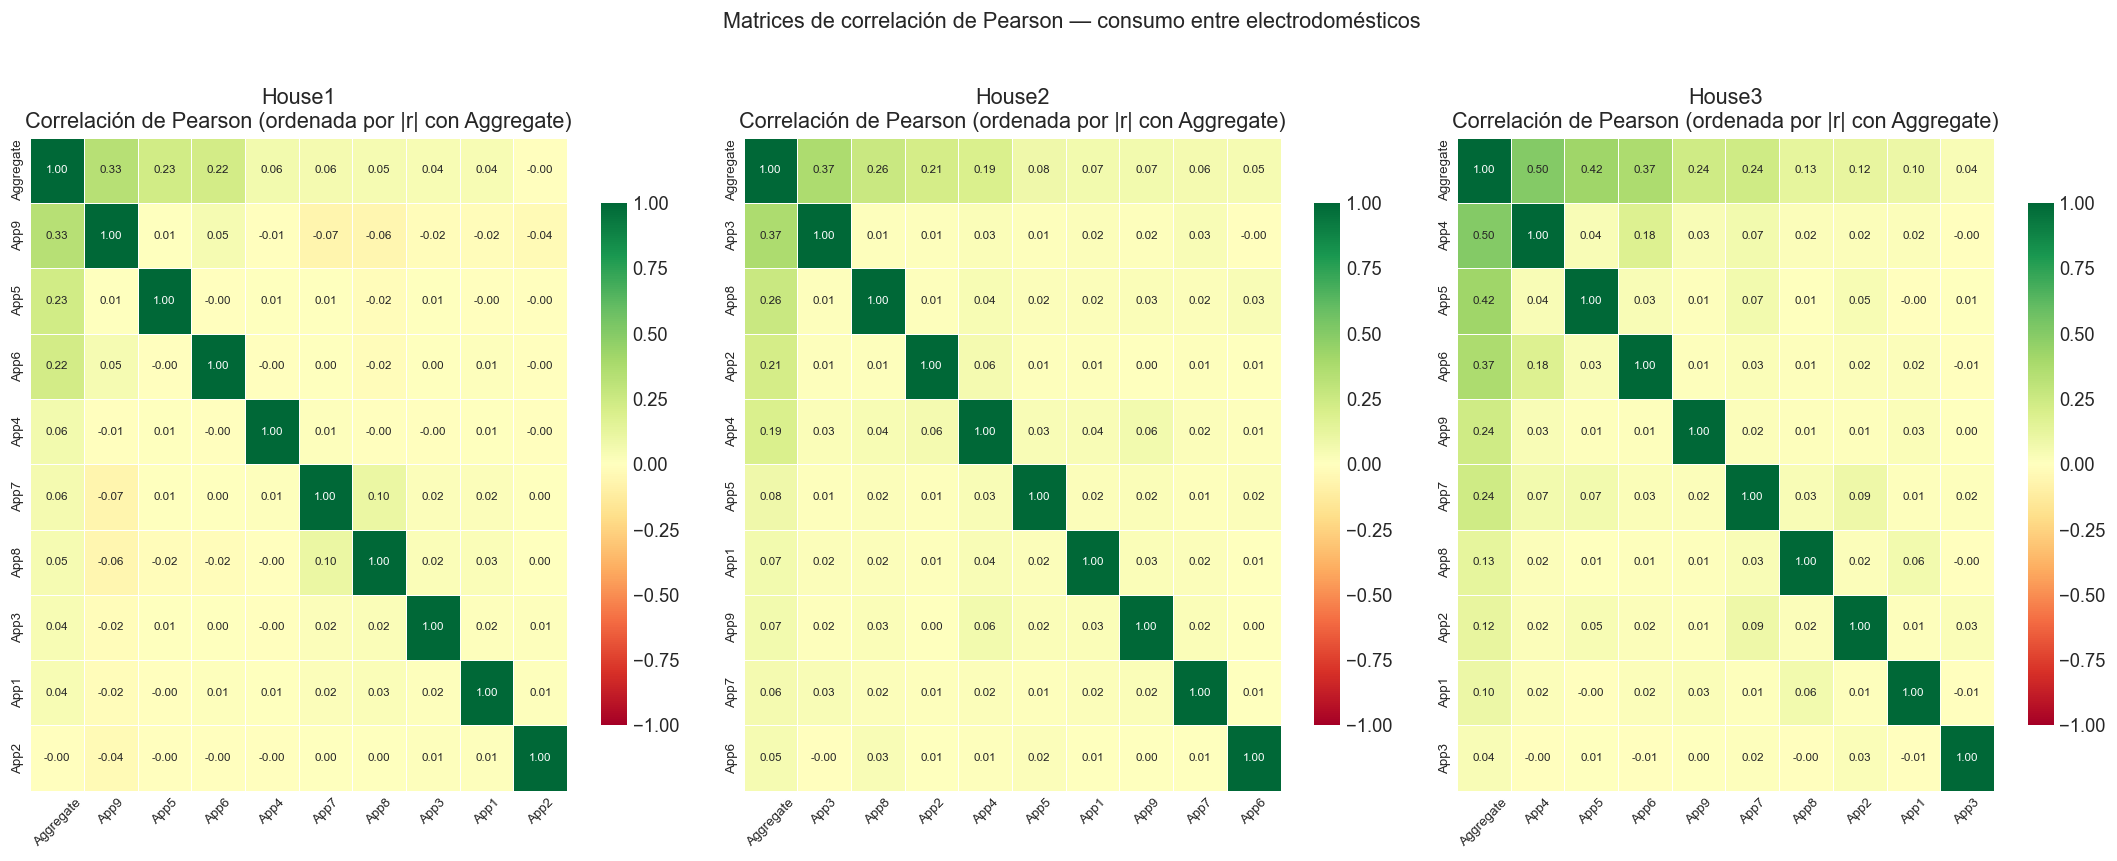

Correlaciones House1 guardadas en resultados/metricas/04_correlaciones_house1.csv


In [8]:
# ============================================================
# Matrices de correlación de Pearson — los 3 hogares
# Ordenadas por correlación con Aggregate
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

correlaciones_export = {}

for ax, hogar in zip(axes, HOGARES):
    df_hogar = datos[hogar][COLS_CONSUMO]

    # Calcular correlación de Pearson
    corr_matrix = df_hogar.corr(method='pearson', min_periods=100)

    # Reordenar columnas/filas por correlación con Aggregate
    orden = corr_matrix['Aggregate'].abs().sort_values(ascending=False).index
    corr_ordenada = corr_matrix.loc[orden, orden]

    # Etiquetas más legibles
    etiquetas = ['Aggregate' if c == 'Aggregate' else c.replace('Appliance', 'App') for c in orden]

    sns.heatmap(
        corr_ordenada,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        vmin=-1, vmax=1,
        xticklabels=etiquetas,
        yticklabels=etiquetas,
        linewidths=0.5,
        annot_kws={'size': 7},
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(f'{hogar}\nCorrelación de Pearson (ordenada por |r| con Aggregate)')
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8)

    correlaciones_export[hogar] = corr_matrix

plt.suptitle('Matrices de correlación de Pearson — consumo entre electrodomésticos', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '04_correlacion_electrodomesticos.png'), bbox_inches='tight')
plt.show()

# Guardar correlaciones de House1 como referencia
correlaciones_export['House1'].to_csv(os.path.join(RUTA_MET, '04_correlaciones_house1.csv'))
print('Correlaciones House1 guardadas en resultados/metricas/04_correlaciones_house1.csv')

## 8. Distribuciones estadísticas <a id='8'></a>

El consumo eléctrico doméstico sigue una distribución **asimétrica positiva (right-skewed)**:
la mayor parte del tiempo el hogar consume una cantidad moderada (stand-by + iluminación),
con picos breves y pronunciados cuando se activan electrodomésticos de alta potencia.

Esta asimetría es relevante porque:
- Los modelos que asumen normalidad (regresión lineal simple, etc.) son menos adecuados.
- Las métricas de error absoluto (MAE, RMSE) se verán dominadas por los picos de consumo.
- La normalización o transformación logarítmica puede mejorar algunos modelos.

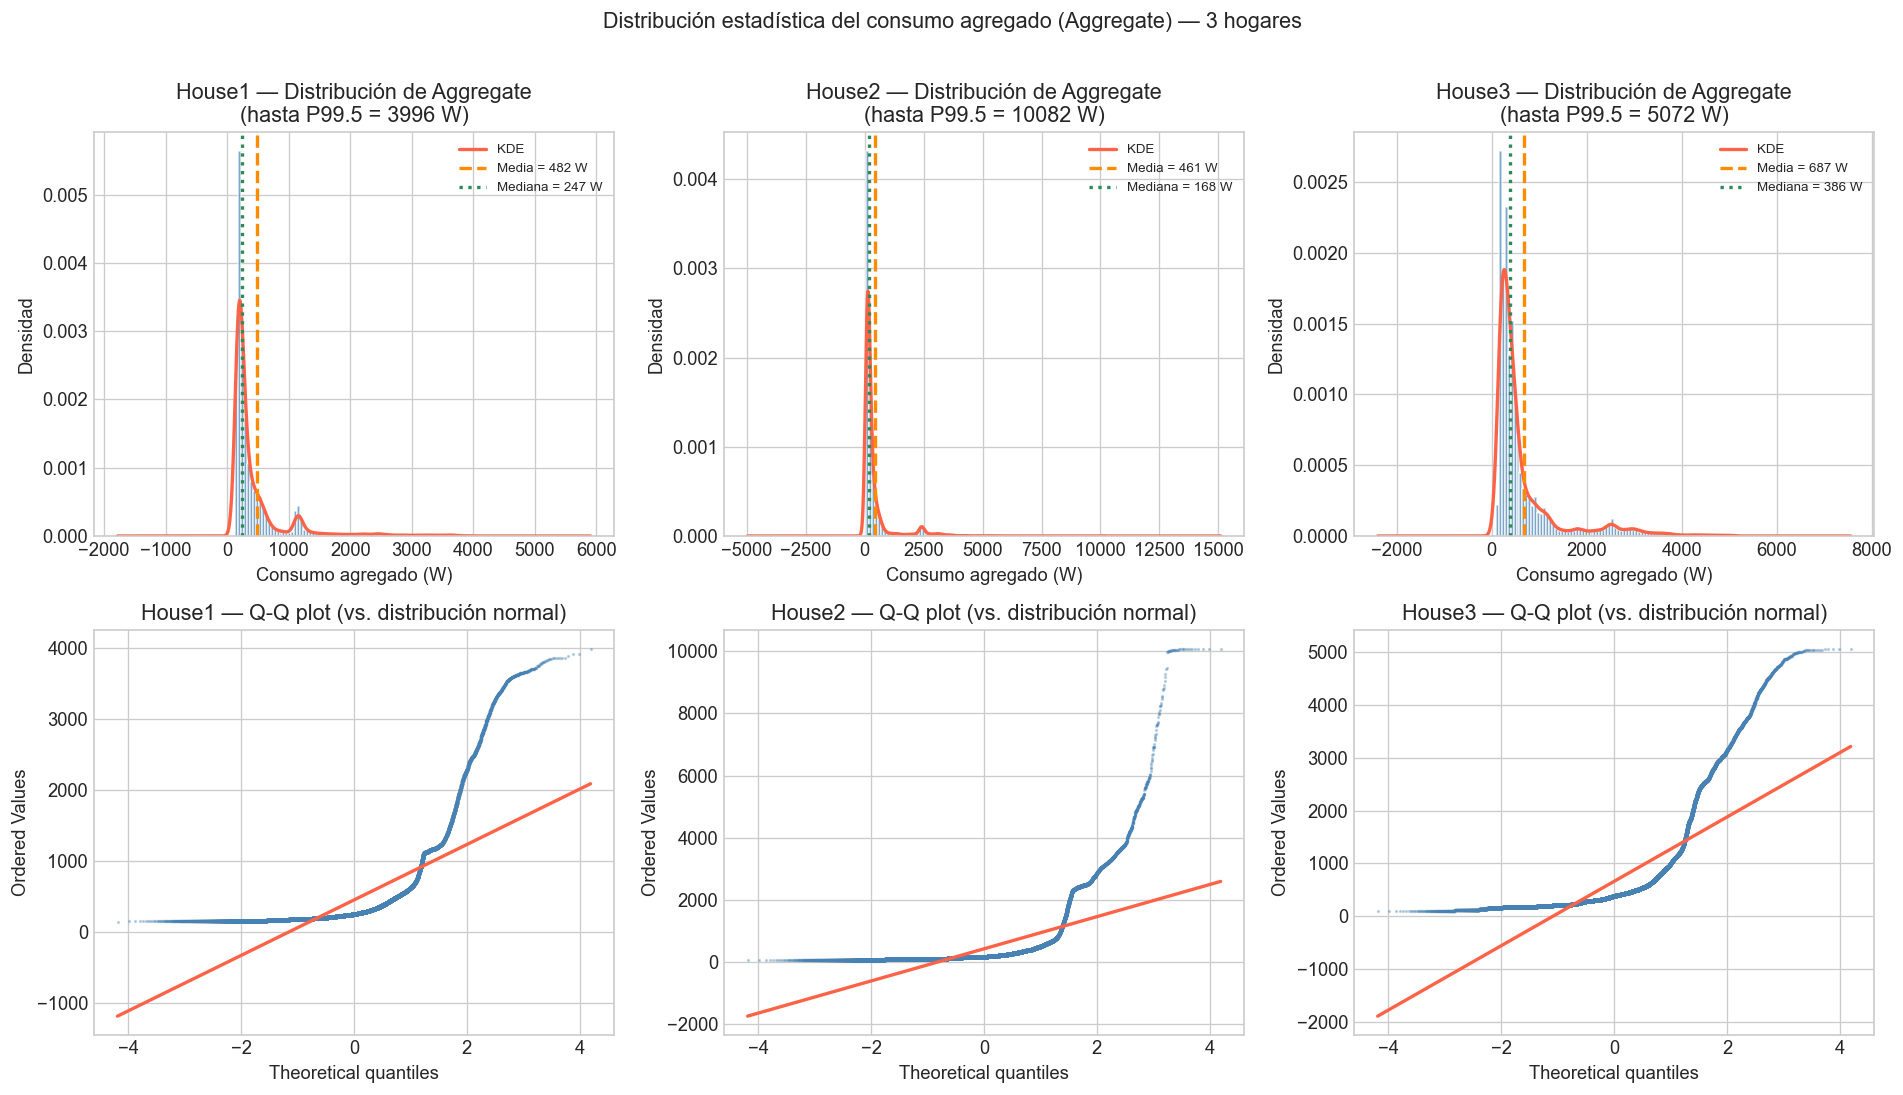

=== Estadísticos de distribución ===


,Media (W),Mediana (W),Desv. est.,P25 (W),P75 (W),P99 (W),Asimetría,Curtosis
Hogar,,,,,,,,
House1,482.1,246.6,765.0,186.5,453.7,3358.0,7.558,84.531
House2,461.4,168.0,1029.0,107.2,333.4,4146.4,6.312,51.768
House3,686.6,385.6,858.1,236.8,657.7,4258.0,3.230,13.732



CSV guardado: resultados/metricas/04_estadisticos_distribucion.csv


In [9]:
# ============================================================
# Histograma + Q-Q plot + estadísticos de distribución
# ============================================================

KDE_MAX_PUNTOS = 50_000  # muestreo para KDE: suficiente visualmente, evita O(n²)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

estadisticos_dist = []

for col, hogar in enumerate(HOGARES):
    serie = datos[hogar]['Aggregate'].dropna()

    ax_hist = axes[0, col]
    p995       = serie.quantile(0.995)
    serie_plot = serie[serie <= p995]

    ax_hist.hist(serie_plot, bins=80, density=True, color='steelblue',
                 alpha=0.7, edgecolor='white')

    # Muestrear para KDE: el resultado visual es indistinguible con 50K puntos
    kde_muestra = serie_plot.sample(min(KDE_MAX_PUNTOS, len(serie_plot)), random_state=SEMILLA)
    kde_muestra.plot.kde(ax=ax_hist, color='tomato', lw=2, label='KDE')

    ax_hist.axvline(serie.mean(),   color='darkorange', lw=2, linestyle='--',
                   label=f'Media = {serie.mean():.0f} W')
    ax_hist.axvline(serie.median(), color='seagreen',   lw=2, linestyle=':',
                   label=f'Mediana = {serie.median():.0f} W')
    ax_hist.set_title(f'{hogar} — Distribución de Aggregate\n(hasta P99.5 = {p995:.0f} W)')
    ax_hist.set_xlabel('Consumo agregado (W)')
    ax_hist.set_ylabel('Densidad')
    ax_hist.legend(fontsize=8)

    ax_qq = axes[1, col]
    stats.probplot(serie_plot.sample(min(KDE_MAX_PUNTOS, len(serie_plot)), random_state=SEMILLA),
                   dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{hogar} — Q-Q plot (vs. distribución normal)')
    ax_qq.get_lines()[0].set(markersize=1, alpha=0.3, color='steelblue')
    ax_qq.get_lines()[1].set(color='tomato', lw=2)

    estadisticos_dist.append({
        'Hogar'      : hogar,
        'Media (W)'  : round(serie.mean(), 1),
        'Mediana (W)': round(serie.median(), 1),
        'Desv. est.' : round(serie.std(), 1),
        'P25 (W)'    : round(serie.quantile(0.25), 1),
        'P75 (W)'    : round(serie.quantile(0.75), 1),
        'P99 (W)'    : round(serie.quantile(0.99), 1),
        'Asimetría'  : round(stats.skew(serie), 3),
        'Curtosis'   : round(stats.kurtosis(serie), 3),
    })

plt.suptitle('Distribución estadística del consumo agregado (Aggregate) — 3 hogares', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '04_distribucion_consumo.png'), bbox_inches='tight')
plt.show()

df_estadisticos = pd.DataFrame(estadisticos_dist).set_index('Hogar')
print('=== Estadísticos de distribución ===')
display(df_estadisticos)

df_estadisticos.to_csv(os.path.join(RUTA_MET, '04_estadisticos_distribucion.csv'))
print('\nCSV guardado: resultados/metricas/04_estadisticos_distribucion.csv')

## 9. Feature Engineering <a id='9'></a>

El feature engineering construye las variables predictoras a partir del timestamp
y del historial de consumo. Las features se organizan en cuatro grupos:

| Grupo | Features | Justificación |
|---|---|---|
| Temporales básicas | hora, dia_semana, mes, etc. | Captura de ciclos diario/semanal/anual |
| Codificaciones cíclicas | sin/cos de hora, mes, dia_semana | Evita discontinuidad en variable periódica |
| Actividad binaria | es_finde, es_festivo_UK | Diferencia de comportamiento documentada en EDA |
| Lags temporales | lag_1 a lag_1440 | Autocorrelación fuerte a corto/medio plazo (ACF) |
| Estadísticos de ventana | media_móvil, std_móvil | Inercia del consumo y volatilidad local |

In [10]:
# ============================================================
# Función para añadir features a un DataFrame de un hogar
# ============================================================

def agregar_features(df: pd.DataFrame, festivos: set) -> pd.DataFrame:
    """
    Añade todas las features predictoras al DataFrame.
    El índice debe ser un DatetimeIndex con frecuencia 1 min.
    """
    df = df.copy()
    idx = df.index

    # --- Variables temporales básicas ---
    df['hora']        = idx.hour
    df['minuto']      = idx.minute
    df['dia_semana']  = idx.dayofweek          # 0 = lunes, 6 = domingo
    df['dia_mes']     = idx.day
    df['dia_anyo']    = idx.dayofyear
    df['semana_anyo'] = idx.isocalendar().week.astype(int)
    df['mes']         = idx.month
    df['trimestre']   = idx.quarter
    df['anyo']        = idx.year

    # map() vectorizado: ~20-50x más rápido que apply() en 900K filas
    df['estacion'] = df['mes'].map(_ESTACION_MAP)

    # --- Variables binarias de actividad ---
    df['es_finde']      = (df['dia_semana'] >= 5).astype(np.int8)
    fechas_dia          = idx.normalize()
    df['es_festivo_uk'] = fechas_dia.isin(festivos).astype(np.int8)

    # --- Codificaciones cíclicas (sin/cos) ---
    df['hora_sin']       = np.sin(2 * np.pi * df['hora'] / 24)
    df['hora_cos']       = np.cos(2 * np.pi * df['hora'] / 24)
    df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)
    df['mes_sin']        = np.sin(2 * np.pi * (df['mes'] - 1) / 12)
    df['mes_cos']        = np.cos(2 * np.pi * (df['mes'] - 1) / 12)
    df['dia_anyo_sin']   = np.sin(2 * np.pi * df['dia_anyo'] / 365)
    df['dia_anyo_cos']   = np.cos(2 * np.pi * df['dia_anyo'] / 365)

    # --- Lags temporales (basados en ACF/PACF) ---
    for lag in [1, 5, 15, 30, 60, 1440, 2880, 10080]:
        df[f'lag_{lag}'] = df['Aggregate'].shift(lag)

    # --- Estadísticos de ventana deslizante ---
    for ventana in [15, 30, 60, 1440]:
        df[f'media_movil_{ventana}'] = (
            df['Aggregate'].rolling(window=ventana, min_periods=1).mean()
        )
        if ventana in [60, 1440]:
            df[f'std_movil_{ventana}'] = (
                df['Aggregate'].rolling(window=ventana, min_periods=2).std()
            )

    df['min_movil_60'] = df['Aggregate'].rolling(window=60, min_periods=1).min()
    df['max_movil_60'] = df['Aggregate'].rolling(window=60, min_periods=1).max()

    return df


print('Función agregar_features definida.')
print(f'Features de actividad binaria: {len(FESTIVOS_UK)} festivos UK disponibles.')

Función agregar_features definida.
Features de actividad binaria: 16 festivos UK disponibles.


In [11]:
# ============================================================
# Aplicar feature engineering a los tres hogares
# ============================================================

datos_features = {}

for hogar in HOGARES:
    print(f'Procesando {hogar}...', end=' ')
    df_feat = agregar_features(datos[hogar], FESTIVOS_UK)
    datos_features[hogar] = df_feat

    # Resumen de features creadas
    n_features = len([c for c in df_feat.columns if c not in COLS_CONSUMO])
    print(f'{n_features} features añadidas | Shape final: {df_feat.shape}')

# Mostrar listado de features con descripción
features_creadas = [
    c for c in datos_features['House1'].columns if c not in COLS_CONSUMO
]
print(f'\nTotal de features: {len(features_creadas)}')
print('\n'.join([f'  - {f}' for f in features_creadas]))

Procesando House1... 

36 features añadidas | Shape final: (920091, 46)
Procesando House2... 

36 features añadidas | Shape final: (889078, 46)
Procesando House3... 

36 features añadidas | Shape final: (885095, 46)

Total de features: 36
  - hora
  - minuto
  - dia_semana
  - dia_mes
  - dia_anyo
  - semana_anyo
  - mes
  - trimestre
  - anyo
  - estacion
  - es_finde
  - es_festivo_uk
  - hora_sin
  - hora_cos
  - dia_semana_sin
  - dia_semana_cos
  - mes_sin
  - mes_cos
  - dia_anyo_sin
  - dia_anyo_cos
  - lag_1
  - lag_5
  - lag_15
  - lag_30
  - lag_60
  - lag_1440
  - lag_2880
  - lag_10080
  - media_movil_15
  - media_movil_30
  - media_movil_60
  - std_movil_60
  - media_movil_1440
  - std_movil_1440
  - min_movil_60
  - max_movil_60


In [12]:
# ============================================================
# Tabla resumen de todas las features creadas
# Para incluir en la memoria del PFM
# ============================================================

descripcion_features = {
    'hora'              : 'Hora del día (0-23)',
    'minuto'            : 'Minuto de la hora (0-59)',
    'dia_semana'        : 'Día de la semana (0=Lunes, 6=Domingo)',
    'dia_mes'           : 'Día del mes (1-31)',
    'dia_anyo'          : 'Día del año (1-366)',
    'semana_anyo'       : 'Semana ISO del año (1-53)',
    'mes'               : 'Mes del año (1-12)',
    'trimestre'         : 'Trimestre (1-4)',
    'anyo'              : 'Año natural',
    'estacion'          : 'Estación meteorológica (UK)',
    'es_finde'          : 'Indicador fin de semana (0/1)',
    'es_festivo_uk'     : 'Festivo bancario England & Wales (0/1)',
    'hora_sin'          : 'Codificación cíclica: sin(2π·hora/24)',
    'hora_cos'          : 'Codificación cíclica: cos(2π·hora/24)',
    'dia_semana_sin'    : 'Codificación cíclica: sin(2π·dia_semana/7)',
    'dia_semana_cos'    : 'Codificación cíclica: cos(2π·dia_semana/7)',
    'mes_sin'           : 'Codificación cíclica: sin(2π·(mes-1)/12)',
    'mes_cos'           : 'Codificación cíclica: cos(2π·(mes-1)/12)',
    'dia_anyo_sin'      : 'Codificación cíclica: sin(2π·dia_anyo/365)',
    'dia_anyo_cos'      : 'Codificación cíclica: cos(2π·dia_anyo/365)',
    'lag_1'             : 'Consumo hace 1 minuto (W)',
    'lag_5'             : 'Consumo hace 5 minutos (W)',
    'lag_15'            : 'Consumo hace 15 minutos (W)',
    'lag_30'            : 'Consumo hace 30 minutos (W)',
    'lag_60'            : 'Consumo hace 1 hora (W)',
    'lag_1440'          : 'Consumo mismo instante ayer (W)',
    'lag_2880'          : 'Consumo mismo instante hace 2 días (W)',
    'lag_10080'         : 'Consumo mismo instante hace 7 días (W)',
    'media_movil_15'    : 'Media móvil últimos 15 min (W)',
    'media_movil_30'    : 'Media móvil últimos 30 min (W)',
    'media_movil_60'    : 'Media móvil última hora (W)',
    'media_movil_1440'  : 'Media móvil últimas 24h (W)',
    'std_movil_60'      : 'Desv. típica móvil última hora (W) — volatilidad',
    'std_movil_1440'    : 'Desv. típica móvil últimas 24h (W)',
    'min_movil_60'      : 'Mínimo móvil última hora (W)',
    'max_movil_60'      : 'Máximo móvil última hora (W)',
}

df_tabla_features = pd.DataFrame([
    {'Feature': k, 'Descripción': v}
    for k, v in descripcion_features.items()
    if k in features_creadas
])
df_tabla_features.index = range(1, len(df_tabla_features) + 1)

print(f'=== Catálogo de features ({len(df_tabla_features)} en total) ===')
display(df_tabla_features)

df_tabla_features.to_csv(os.path.join(RUTA_MET, '04_catalogo_features.csv'), index_label='Nº')
print('\nCSV guardado: resultados/metricas/04_catalogo_features.csv')

=== Catálogo de features (36 en total) ===


,Feature,Descripción
1,hora,Hora del día (0-23)
2,minuto,Minuto de la hora (0-59)
3,dia_semana,"Día de la semana (0=Lunes, 6=Domingo)"
4,dia_mes,Día del mes (1-31)
5,dia_anyo,Día del año (1-366)
6,semana_anyo,Semana ISO del año (1-53)
7,mes,Mes del año (1-12)
8,trimestre,Trimestre (1-4)
9,anyo,Año natural
10,estacion,Estación meteorológica (UK)



CSV guardado: resultados/metricas/04_catalogo_features.csv


## 10. Correlación de features con el target <a id='10'></a>

La correlación de Pearson entre cada feature y `Aggregate` ofrece una primera
estimación de su poder predictivo **lineal**. Es una métrica imperfecta (no captura
relaciones no lineales), pero orienta sobre qué features tienen más información y
sirve de referencia para la selección de variables en el modelado.

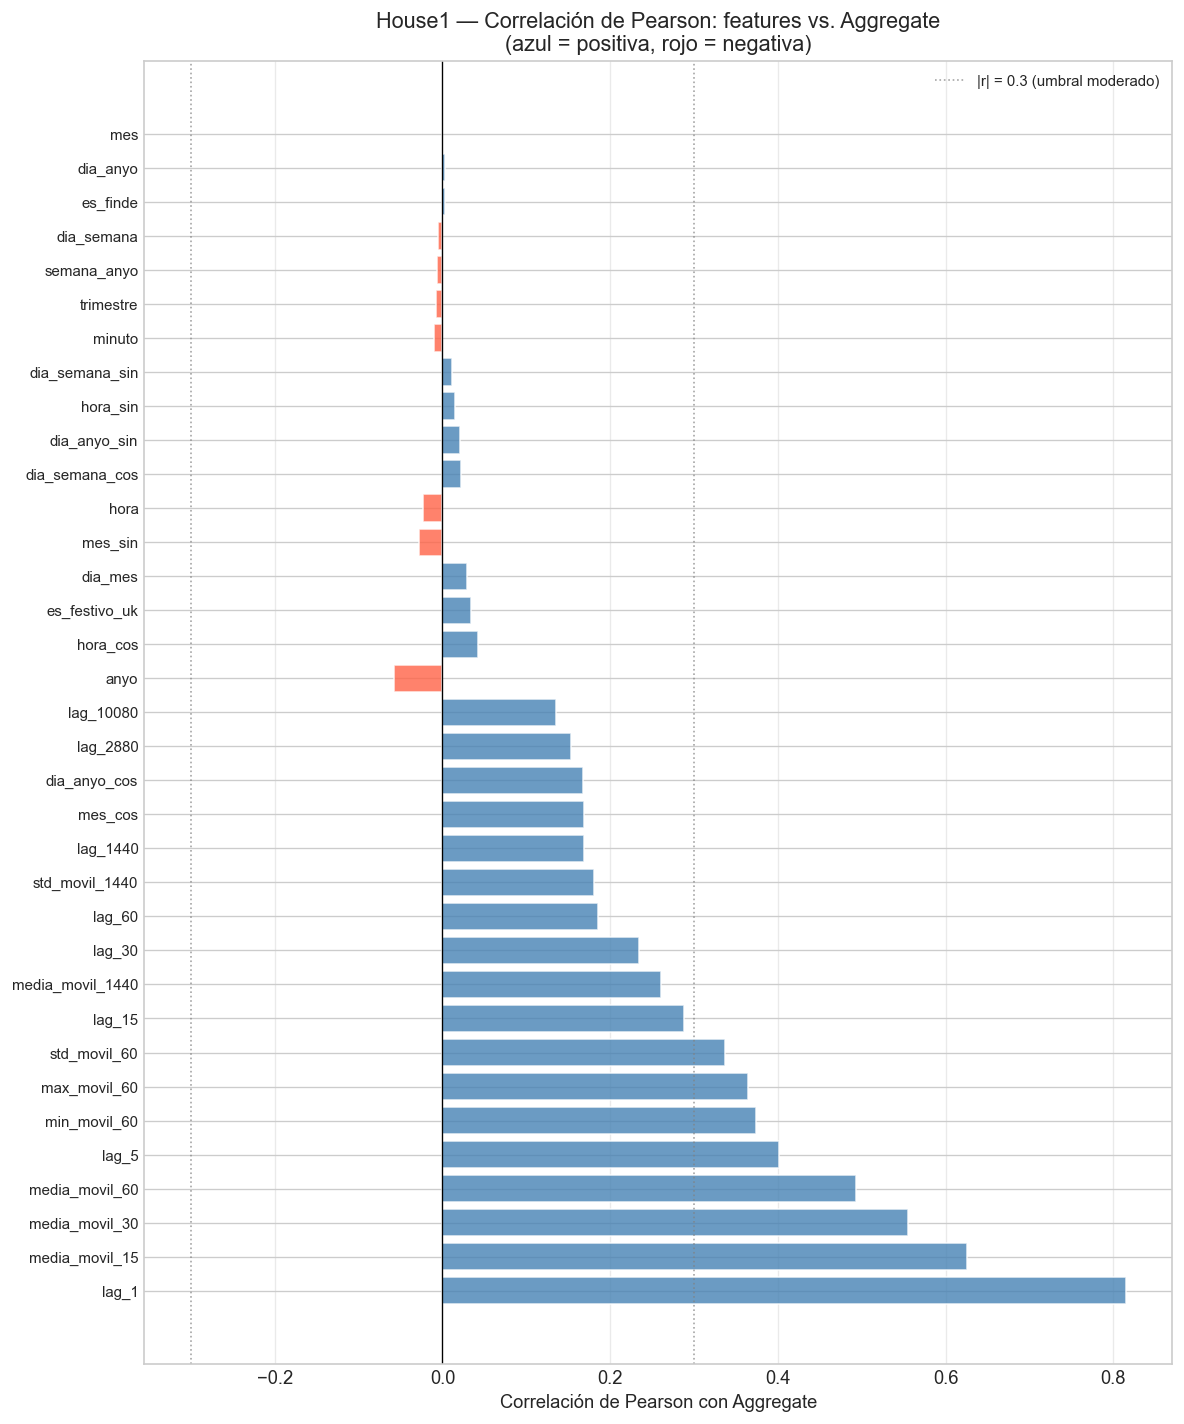

=== Top 10 features más correlacionadas (|r|) con Aggregate ===


,Feature,r_pearson,p_valor
0,lag_1,0.814857,0.0
1,media_movil_15,0.625317,0.0
2,media_movil_30,0.555653,0.0
3,media_movil_60,0.492855,0.0
4,lag_5,0.401937,0.0
5,min_movil_60,0.373926,0.0
6,max_movil_60,0.364003,0.0
7,std_movil_60,0.337179,0.0
8,lag_15,0.287505,0.0
9,media_movil_1440,0.260734,0.0



CSV guardado: resultados/metricas/04_features_correlacion_target.csv


In [13]:
# ============================================================
# Correlación de Pearson de cada feature numérica con Aggregate
# Se calcula sobre House1 (menos NaN, más representativo)
# ============================================================

df_h1 = datos_features['House1']

# is_numeric_dtype cubre todos los subtipos numéricos (float32/64, int8/16/32/64…)
features_num = [
    c for c in features_creadas
    if pd.api.types.is_numeric_dtype(df_h1[c])
]

# Un único dropna sobre todas las columnas a la vez: 1 asignación en lugar de ~34
df_corr_base = df_h1[['Aggregate'] + features_num].dropna()

correlaciones = []
for feat in features_num:
    if len(df_corr_base) < 100:
        continue
    r, p = stats.pearsonr(df_corr_base['Aggregate'], df_corr_base[feat])
    correlaciones.append({'Feature': feat, 'r_pearson': r, '|r|': abs(r), 'p_valor': p})

df_corr_features = pd.DataFrame(correlaciones).sort_values('|r|', ascending=False)

# Visualización: barras horizontales ordenadas por |r|
fig, ax = plt.subplots(figsize=(10, 12))

colores_bar = ['tomato' if r < 0 else 'steelblue' for r in df_corr_features['r_pearson']]
ax.barh(
    range(len(df_corr_features)),
    df_corr_features['r_pearson'],
    color=colores_bar, alpha=0.8, edgecolor='white'
)
ax.set_yticks(range(len(df_corr_features)))
ax.set_yticklabels(df_corr_features['Feature'], fontsize=9)
ax.axvline(x=0,    color='black', lw=0.8)
ax.axvline(x=0.3,  color='gray',  lw=1, linestyle=':', alpha=0.7, label='|r| = 0.3 (umbral moderado)')
ax.axvline(x=-0.3, color='gray',  lw=1, linestyle=':', alpha=0.7)
ax.set_xlabel('Correlación de Pearson con Aggregate')
ax.set_title('House1 — Correlación de Pearson: features vs. Aggregate\n(azul = positiva, rojo = negativa)')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, '04_features_correlacion.png'), bbox_inches='tight')
plt.show()

print('=== Top 10 features más correlacionadas (|r|) con Aggregate ===')
display(df_corr_features.head(10)[['Feature', 'r_pearson', 'p_valor']].reset_index(drop=True))

df_corr_features.to_csv(os.path.join(RUTA_MET, '04_features_correlacion_target.csv'), index=False)
print('\nCSV guardado: resultados/metricas/04_features_correlacion_target.csv')

## 11. Guardado y verificación final <a id='11'></a>

In [14]:
# ============================================================
# Guardar datasets con features en datos/processed/
# ============================================================

print('=== Guardando datasets con features ===')
for hogar, df in datos_features.items():
    nombre   = f'{hogar.lower()}_features.csv'
    ruta_out = os.path.join(RUTA_PROCESSED, nombre)
    df.to_csv(ruta_out)
    tam_mb = os.path.getsize(ruta_out) / 1024**2
    print(f'  OK  {nombre}  ({len(df):,} filas × {df.shape[1]} columnas | {tam_mb:.1f} MB)')

print('\nTodos los archivos guardados correctamente.')

=== Guardando datasets con features ===


  OK  house1_features.csv  (920,091 filas × 46 columnas | 406.7 MB)


  OK  house2_features.csv  (889,078 filas × 46 columnas | 361.3 MB)


  OK  house3_features.csv  (885,095 filas × 46 columnas | 373.9 MB)

Todos los archivos guardados correctamente.


In [15]:
# ============================================================
# Verificación final de archivos generados
# ============================================================

figuras_esperadas = [
    '04_nan_patrones.png',
    '04_descomposicion_estacional.png',
    '04_acf_pacf.png',
    '04_scatter_lags.png',
    '04_correlacion_electrodomesticos.png',
    '04_distribucion_consumo.png',
    '04_features_correlacion.png',
]
metricas_esperadas = [
    '04_resumen_estacionariedad.csv',
    '04_correlaciones_house1.csv',
    '04_estadisticos_distribucion.csv',
    '04_catalogo_features.csv',
    '04_features_correlacion_target.csv',
]
datos_esperados = [
    'house1_features.csv', 'house2_features.csv', 'house3_features.csv',
]

print('=== VERIFICACIÓN FINAL — NOTEBOOK 04 ===')
print('\nFiguras (resultados/figuras/):')
for f in figuras_esperadas:
    ok = os.path.exists(os.path.join(RUTA_FIGS, f))
    print(f'  {"OK" if ok else "FALTA":5s}  {f}')

print('\nMétricas (resultados/metricas/):')
for f in metricas_esperadas:
    ok = os.path.exists(os.path.join(RUTA_MET, f))
    print(f'  {"OK" if ok else "FALTA":5s}  {f}')

print('\nDatos con features (datos/processed/):')
for f in datos_esperados:
    ok = os.path.exists(os.path.join(RUTA_PROCESSED, f))
    print(f'  {"OK" if ok else "FALTA":5s}  {f}')

print('\n=== NOTEBOOK 04 COMPLETADO ===')
print('Próximo paso: Notebook 05 — Modelado baseline y comparativa de modelos')

=== VERIFICACIÓN FINAL — NOTEBOOK 04 ===

Figuras (resultados/figuras/):
  OK     04_nan_patrones.png
  OK     04_descomposicion_estacional.png
  OK     04_acf_pacf.png
  OK     04_scatter_lags.png
  OK     04_correlacion_electrodomesticos.png
  OK     04_distribucion_consumo.png
  OK     04_features_correlacion.png

Métricas (resultados/metricas/):
  OK     04_resumen_estacionariedad.csv
  OK     04_correlaciones_house1.csv
  OK     04_estadisticos_distribucion.csv
  OK     04_catalogo_features.csv
  OK     04_features_correlacion_target.csv

Datos con features (datos/processed/):
  OK     house1_features.csv
  OK     house2_features.csv
  OK     house3_features.csv

=== NOTEBOOK 04 COMPLETADO ===
Próximo paso: Notebook 05 — Modelado baseline y comparativa de modelos
